처음에는 kaggle에 있는 각국 AI/ML salarie 데이터셋을 이용하여 머신을 학습시키고, 국내의 취업알선 사이트에서 연봉과 feature data를 크롤링 하여 머신의 정확도를 검증하며  
사용자에게 feature data를 입력받아 연봉값을 예측해주는 개발을 하려고 했으나 다음과 같은 문제가 있었습니다   

- 크롤링이 가능한 국내의 취업알선 사이트에서는 feature data를 꽁꽁 숨겨서 크롤링이 불가능할 뿐만 아니라, 가장 중요한 연봉값을 '회사 내규에 따름' 혹은 '협의 후 결정' 과 같은 형태로 숨겨놓아 연봉값을 획득할 수가 없었습니다. 그나마 연봉값이 있는 글은 정확한 연봉값이 아니라 두루뭉실한 범위로 지정해 놓아 데이터로써의 의미가 없없습니다. 수집 할 수 있는 데이터도 몇십개에 불가능 했습니다.

- 학습시킬 AI/ML salarie 데이터셋에는 한국데이터가 거의 없어서 학습에 대한 의미가 퇴색했습니다.   




그래서 이를 해결하기 위해서 다음과 같은 방향으로 문제를 보완하려 했습니다.   

- 조금 더 Data가 많은 데이터 셋을 선택합니다.

- kaggle에에서 얻은 데이터셋에는 공통적으로 세가지 문제가 있습니다.   
feature 중 work_year 가 2020~2023년까지는 데이터가 적고 2024부터 폭발적으로 많아 비율이 맞지 않는것.   
feature 중 company_location는 90% 이상 미국이라는 것.
feature 중 job_title의 종류가 너무 많은 점. One Hot Encoding을 하는데 문제가 됨.


이것을 해결하기 위해   

-> work_year 데이터를 2020~2022년까지 데이터를 합치고, 2023년과 2024데이터를 2000개씩만 뽑아내여 비율을 맞췄습니다. 2025년 data는 test로 활용합니다. 나머지는 train으로 학습시킵니다.   
-> company_location는 미국으로 통일합니다. 한국이 아닌 미국의 AI/ML 들의 연봉을 에측 할 것입니다.   
-> job_title의 중 연봉에 미치는 영향과 직무의 성격에 따라 4분류로 나누었습니다.   


하지만 이렇게 적용했음에도 불구하고 (ex.salaries.ipynb)
예측률이 고작 10%가 나왔는데

- feature 중 work_year를 통한 연도별 연봉을 예측하기 위해 비율을 맞추는 공정 자체가 학습할 Data를 지나치게 줄여버렸습니다.   
AI/ML 직군이 2024년부터 폭발적으로 늘어난 것을 반영했어야 했습니다.    




그래서 이번 ex.newsalaries.ipynb 에서는   

- kaggle 데이터 셋을 벗어나 미국 https://aijobs.net/에서 제공하는 full dataset of global AI, ML, Data salaries 를 활용합니다.   데이터 수가 더 많습니다.

- AI/ML 직군이 2024년부터 폭발적으로 늘어난 것은 어떻게 보정할 방법이 없으니, 처음부터 2024와 2025년도의 데이터 만을 활용합니다.  어차피 2개년도의 데이터가 90% 이상입니다. 이것으로 work_year의 비율을 맞출 수 있습니다.

- 해당 데이터셋을 모두 train에 활용합니다.(물론 검증을 위해 valid로 나눕니다.) test데이터는 직접 크롤링 해서 얻은 data로 test할 것입니다.

In [64]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import xgboost as xgb
from sklearn.svm import SVR

# For interactive visualizations
import plotly.io as pio
pio.templates.default = "plotly_white"

# Suppress warnings
warnings.filterwarnings('ignore')

# Set styling
sns.set(style="whitegrid")
plt.style.use('fivethirtyeight')

In [65]:
df = pd.read_csv("../Data/salarie.csv")
# Initial overview
print(f"Dataset Shape: {df.shape}")
print(f"\nMemory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print("\nFirst few rows:")
df.head()

Dataset Shape: (141566, 11)

Memory Usage: 11.88 MB

First few rows:


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EN,FT,Data Quality Analyst,60000,GBP,75949,GB,0,GB,M
1,2025,EN,FT,Data Quality Analyst,48000,GBP,60759,GB,0,GB,M
2,2025,SE,FT,Applied Scientist,266000,USD,266000,US,0,US,M
3,2025,SE,FT,Applied Scientist,204000,USD,204000,US,0,US,M
4,2025,SE,FT,Data Scientist,291000,USD,291000,US,0,US,M


In [66]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141566 entries, 0 to 141565
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           141566 non-null  int64 
 1   experience_level    141566 non-null  object
 2   employment_type     141566 non-null  object
 3   job_title           141566 non-null  object
 4   salary              141566 non-null  int64 
 5   salary_currency     141566 non-null  object
 6   salary_in_usd       141566 non-null  int64 
 7   employee_residence  141566 non-null  object
 8   remote_ratio        141566 non-null  int64 
 9   company_location    141566 non-null  object
 10  company_size        141566 non-null  object
dtypes: int64(4), object(7)
memory usage: 11.9+ MB


In [67]:
# Statistical summary of numerical columns
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
work_year,141566.000000,2024.395907,0.677544,2020.000000,2024.000000,2024.000000,2025.000000,2025.000000
salary,141566.000000,162971.880628,212678.100536,14000.000000,106000.000000,147000.000000,198873.250000,30400000.000000
salary_in_usd,141566.000000,157496.750682,74132.383476,15000.000000,106000.000000,146147.500000,198000.000000,800000.000000
remote_ratio,141566.000000,20.963720,40.634986,0.000000,0.000000,0.000000,0.000000,100.000000


In [68]:
# Check for missing values # 없음
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percent
})

print("Missing values check:")
missing_df[missing_df['Missing Values'] > 0]

Missing values check:


,Missing Values,Percentage


In [69]:
df.company_location.value_counts()

company_location
US    126870
CA      5678
GB      3923
AU       548
NL       432
       ...  
QA         1
MU         1
GI         1
OM         1
MD         1
Name: count, Length: 96, dtype: int64

In [70]:
# 미국 데이터 제외 나머지 걸러내기
df = df[df['company_location'] == 'US'].copy()

df.company_location.value_counts()

company_location
US    126870
Name: count, dtype: int64

In [71]:
df.work_year.value_counts()

work_year
2025    61221
2024    56574
2023     7602
2022     1341
2021       99
2020       33
Name: count, dtype: int64

In [72]:
# 2024 또는 2025년 데이터만 필터링
df = df[df['work_year'].isin([2024, 2025])].copy()

# 결과 확인
print(df['work_year'].value_counts())

work_year
2025    61221
2024    56574
Name: count, dtype: int64


In [73]:
from sklearn.model_selection import train_test_split

# 전체 데이터프레임을 먼저 분할
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)

print(train_df.shape, valid_df.shape)

(94236, 11) (23559, 11)


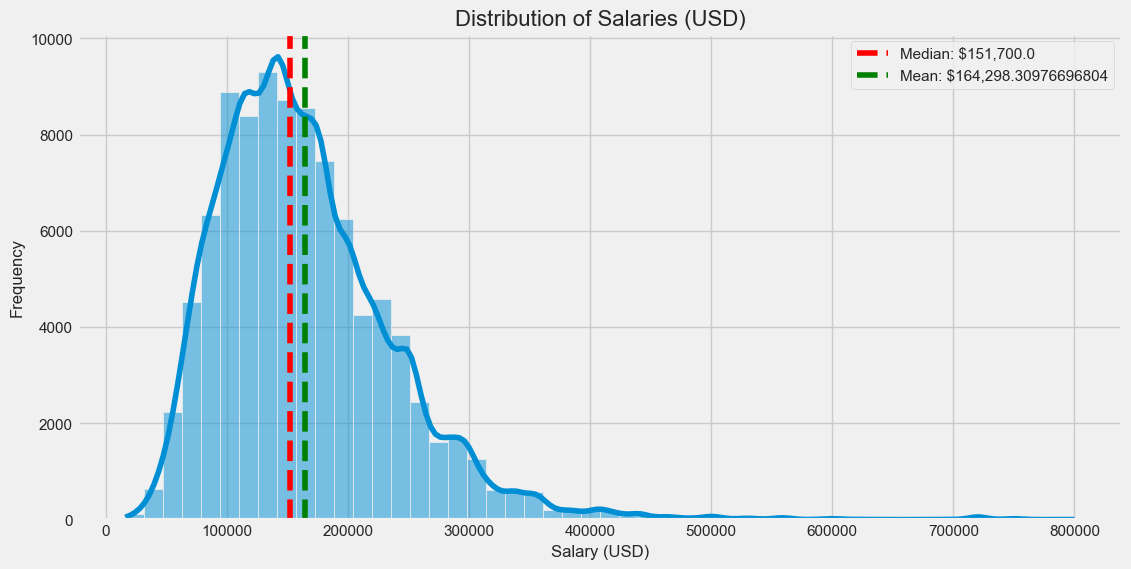

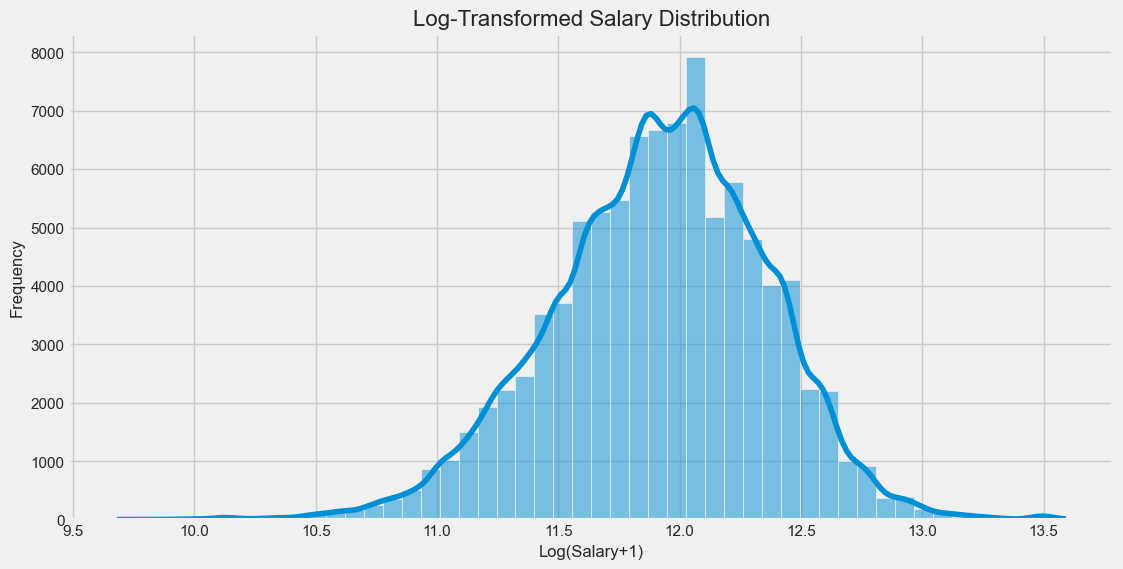

In [74]:
# Distribution of salaries in USD
plt.figure(figsize=(12, 6))
sns.histplot(train_df['salary_in_usd'], kde=True, bins=50)
plt.title('Distribution of Salaries (USD)', fontsize=16)
plt.xlabel('Salary (USD)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(train_df['salary_in_usd'].median(), color='red', linestyle='--', label=f'Median: ${df["salary_in_usd"].median():,}')
plt.axvline(train_df['salary_in_usd'].mean(), color='green', linestyle='--', label=f'Mean: ${df["salary_in_usd"].mean():,}')
plt.legend()
plt.show()

# Log-transformed salary distribution (to handle skewness)
plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(train_df['salary_in_usd']), kde=True, bins=50)
plt.title('Log-Transformed Salary Distribution', fontsize=16)
plt.xlabel('Log(Salary+1)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

판단 근거: 왜 로그 변환이 필요할까?

1. 분포가 오른쪽으로 치우쳐 있음 (우측 비대칭, Right-skewed)
	•	히스토그램에서 **대부분의 값은 낮은 연봉 구간(예: $30k~$100k)**에 몰려 있고,
	•	**높은 연봉 구간(예: $200k 이상)**은 드물지만 아주 높은 값들이 존재합니다.
	•	이로 인해 분포의 꼬리가 오른쪽으로 길게 늘어나는 형태가 되며, 이는 전형적인 우측 비대칭입니다.

2. 평균(Mean)이 중앙값(Median)보다 오른쪽에 위치하고 있다면 → 극단적인 고액 연봉이 평균을 끌어올리는 상황이라는 뜻입니다.


고액 연봉 등의 극단값 영향 완화
선형 모델의 성능 저하
모델 학습 안정성 증가, 예측 정확도 향상
분산이 크고 값 범위가 큼
값의 스케일 축소, 스케일 균형 조정 가능

In [75]:
# 로그 변환
train_df['log_salary'] = np.log1p(train_df['salary_in_usd'])

# IQR 기반 이상치 경계 계산
Q1 = train_df['log_salary'].quantile(0.25)
Q3 = train_df['log_salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 이상치가 아닌 데이터만 남김
train_df = train_df[(train_df['log_salary'] >= lower_bound) & (train_df['log_salary'] <= upper_bound)].copy()

# 불필요한 log column 제거
train_df.drop(columns=['log_salary'], inplace=True)

# 결과 확인 (옵션)
print("이상치 제거 후 데이터 수:", len(train_df))

이상치 제거 후 데이터 수: 93231


In [76]:
# Yearly salary trends
yearly_stats = train_df.groupby('work_year')['salary_in_usd'].agg(['mean', 'median', 'std']).reset_index()

fig = px.line(yearly_stats, x='work_year', y=['mean', 'median'], 
              title='Data Science Salary Trends (2024-2025)',
              labels={'value': 'Salary (USD)', 'work_year': 'Year', 'variable': 'Metric'},
              template='plotly_white')

fig.update_layout(legend_title_text='', hovermode='x unified',
                 width=900, height=500)

# Add range for standard deviation
fig.add_trace(go.Scatter(
    x=np.concatenate([yearly_stats['work_year'], yearly_stats['work_year'][::-1]]),
    y=np.concatenate([yearly_stats['mean'] + yearly_stats['std'], 
                     (yearly_stats['mean'] - yearly_stats['std'])[::-1]]),
    fill='toself',
    fillcolor='rgba(0,100,80,0.2)',
    line=dict(color='rgba(255,255,255,0)'),
    name='Standard Deviation'
))

fig.show()

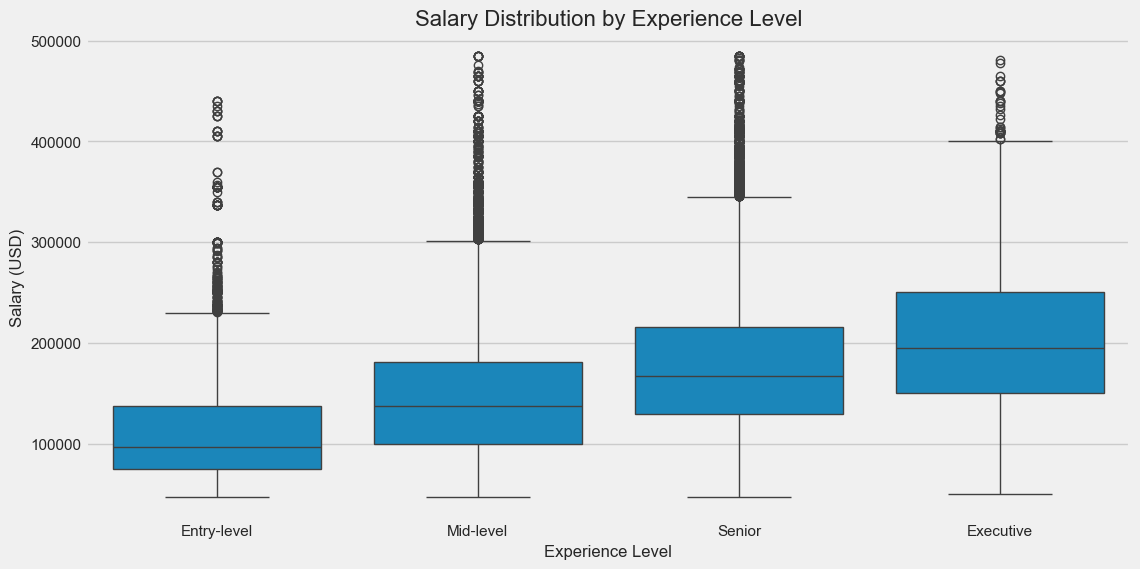

In [77]:
# Experience level salary comparison
plt.figure(figsize=(12, 6))
sns.boxplot(x='experience_level', y='salary_in_usd', data=train_df, order=['EN', 'MI', 'SE', 'EX'])
plt.title('Salary Distribution by Experience Level', fontsize=16)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.xticks(ticks=[0, 1, 2, 3], labels=['Entry-level', 'Mid-level', 'Senior', 'Executive'])
plt.show()

# Mean salary by experience level over time
exp_time = train_df.groupby(['work_year', 'experience_level'])['salary_in_usd'].mean().reset_index()
exp_time['experience_level'] = exp_time['experience_level'].replace({
    'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'
})

fig = px.line(exp_time, x='work_year', y='salary_in_usd', color='experience_level',
             title='Salary Trends by Experience Level (2024-2025)',
             labels={'salary_in_usd': 'Average Salary (USD)', 'work_year': 'Year'},
             template='plotly_white')

fig.update_layout(width=900, height=500, hovermode='x unified')
fig.show()

경력 수준(experience_level)은 연봉에 큰 영향을 미치며, 특히 Executive(임원급, EX)는 다른 수준보다 월등히 높은 연봉을 받습니다

Distribution of top job titles:
job_title
Software Engineer            11830
Data Scientist               11240
Data Engineer                 9137
Data Analyst                  7720
Engineer                      7492
Machine Learning Engineer     5329
Manager                       5186
Analyst                       3240
Research Scientist            2318
Product Manager               1788
Associate                     1581
Applied Scientist             1533
Data Architect                1330
AI Engineer                   1226
Analytics Engineer            1186
Name: count, dtype: int64


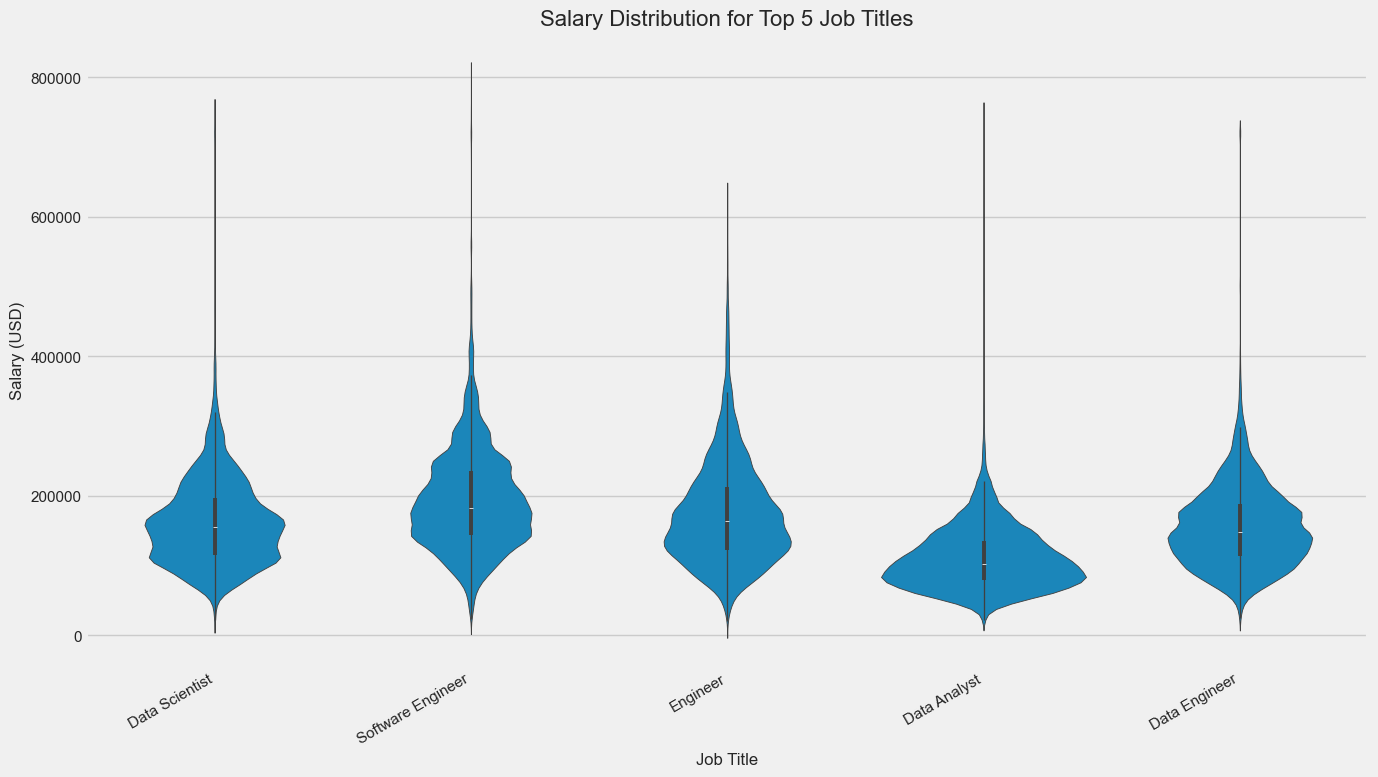

In [78]:
# Top 15 job titles by count
top_jobs = train_df['job_title'].value_counts().head(15)
print("Distribution of top job titles:")
print(top_jobs)

# Mean salary for top job titles
top_jobs_salary = train_df[train_df['job_title'].isin(top_jobs.index)].groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False)

fig = px.bar(x=top_jobs_salary.index, y=top_jobs_salary.values,
            labels={'x': 'Job Title', 'y': 'Average Salary (USD)'},
            title='Average Salary by Top Job Titles',
            color=top_jobs_salary.values, color_continuous_scale='Viridis')

fig.update_layout(xaxis_tickangle=-45, width=1000, height=600)
fig.show()

# Salary distribution for top 5 job titles
plt.figure(figsize=(14, 8))
top5_jobs = top_jobs.index[:5]
sns.violinplot(x='job_title', y='salary_in_usd', data=df[df['job_title'].isin(top5_jobs)])
plt.title('Salary Distribution for Top 5 Job Titles', fontsize=16)
plt.xlabel('Job Title', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

	•	**머신러닝 엔지니어(Machine Learning Engineer)**와 **리서치 사이언티스트(Research Scientist)**는 가장 높은 연봉을 받는 경향이 있습니다.
	•	반면, **데이터 애널리스트(Data Analyst)**는 상대적으로 낮은 연봉을 받습니다.
	•	**소프트웨어 엔지니어(Software Engineer)**는 연봉 분포가 가장 넓게 나타나는데, 이는 해당 직무가 포함하는 역할과 범위가 매우 다양하기 때문입니다.

In [79]:
# Salary by remote ratio
remote_salary = train_df.groupby('remote_ratio')['salary_in_usd'].agg(['mean', 'median', 'count']).reset_index()
remote_salary['remote_ratio'] = remote_salary['remote_ratio'].map({0: 'On-site', 50: 'Hybrid', 100: 'Remote'})

fig = px.bar(remote_salary, x='remote_ratio', y=['mean', 'median'],
            barmode='group', title='Salary by Remote Work Ratio',
            labels={'value': 'Salary (USD)', 'remote_ratio': 'Work Setting', 'variable': 'Metric'},
            color_discrete_sequence=['#2a9d8f', '#e76f51'])

fig.update_layout(width=800, height=500)
fig.show()

# Remote ratio trends over time
remote_time = train_df.groupby(['work_year', 'remote_ratio']).size().reset_index(name='count')
total_per_year = remote_time.groupby('work_year')['count'].sum().reset_index()
remote_time = remote_time.merge(total_per_year, on='work_year', suffixes=('', '_total'))
remote_time['percentage'] = (remote_time['count'] / remote_time['count_total']) * 100
remote_time['remote_ratio'] = remote_time['remote_ratio'].map({0: 'On-site', 50: 'Hybrid', 100: 'Remote'})

fig = px.line(remote_time, x='work_year', y='percentage', color='remote_ratio',
             title='Remote Work Trends (2024-2025)',
             labels={'percentage': 'Percentage of Jobs', 'work_year': 'Year'},
             template='plotly_white')

fig.update_layout(width=900, height=500, hovermode='x unified')
fig.show()

2024년 이후로 코로나가 종식되면서 원격근무와 출근을 혼합한 hybrid 근무형태는 거의 사라져서 기업의 출근 : 원격근무는 형태는 80 : 20 비율을 보여주고 있습니다.
이제는 원격근무 형태라고 연봉이 더 높지는 않습니다.

In [80]:
# Salary by company size
company_salary = train_df.groupby(['company_size', 'experience_level'])['salary_in_usd'].median().reset_index()
company_salary['company_size'] = company_salary['company_size'].map({'S': 'Small', 'M': 'Medium', 'L': 'Large'})
company_salary['experience_level'] = company_salary['experience_level'].map({
    'EN': 'Entry-level', 'MI': 'Mid-level', 'SE': 'Senior', 'EX': 'Executive'
})

fig = px.bar(company_salary, x='company_size', y='salary_in_usd', color='experience_level',
            barmode='group', title='Median Salary by Company Size and Experience Level',
            labels={'salary_in_usd': 'Median Salary (USD)', 'company_size': 'Company Size'},
            template='plotly_white')

fig.update_layout(width=900, height=500)
fig.show()

✅ 전체 해석 요약
	•	**대기업(Large)**은 대부분의 경력 수준에서 더 높은 중앙값 연봉을 제공합니다.  
	•	**중소기업(Small, Medium)**은 경력에 따라 보상 체계가 다소 불균형하거나 변동성이 큼을 보여줍니다.  
  
⸻

🔍 세부 해석  

🔸 대기업 (Large)  
	•	경력이 높을수록 연봉도 증가합니다.  
	•	**Senior(보라색)**의 중앙값이 가장 높고, **Entry-level(파랑)**이 가장 낮습니다.  
	•	대기업은 조직의 규모와 예산 덕분에 각 계층에 대해 비교적 안정적이고 예측 가능한 보상을 제공합니다.  
  
🔸 중간 규모 기업 (Medium)  
	•	**Executive(빨강)**의 중앙값 연봉이 가장 높습니다. 이는 리더십에 대한 높은 보상을 보여줍니다.  
	•	그러나 Entry-level의 연봉은 상대적으로 낮음 → 경력 적은 직원에 대한 투자 여력이 부족할 수 있습니다.  
  
🔸 소규모 기업 (Small)  
	•	특이하게도 **Mid-level(초록색)**이 모든 그룹 중 가장 높은 중앙값 연봉을 가집니다.  
	•	이는 핵심 실무자 중심의 보상 구조로 해석 가능  
	•	Executive와 Senior의 연봉은 오히려 중간 수준  
	•	관리직보다는 실무 중심 보상이 이뤄지는 구조일 수 있음  
  
⸻  
  
🧠 결론 요약
	•	대기업: 전체적으로 고르게 높은 연봉 제공  
	•	중견기업: Executive에게 집중 보상  
	•	소기업: 실무자(Mid-level)에게 집중 보상, 의사결정자가 실무를 겸하는 구조일 가능성  

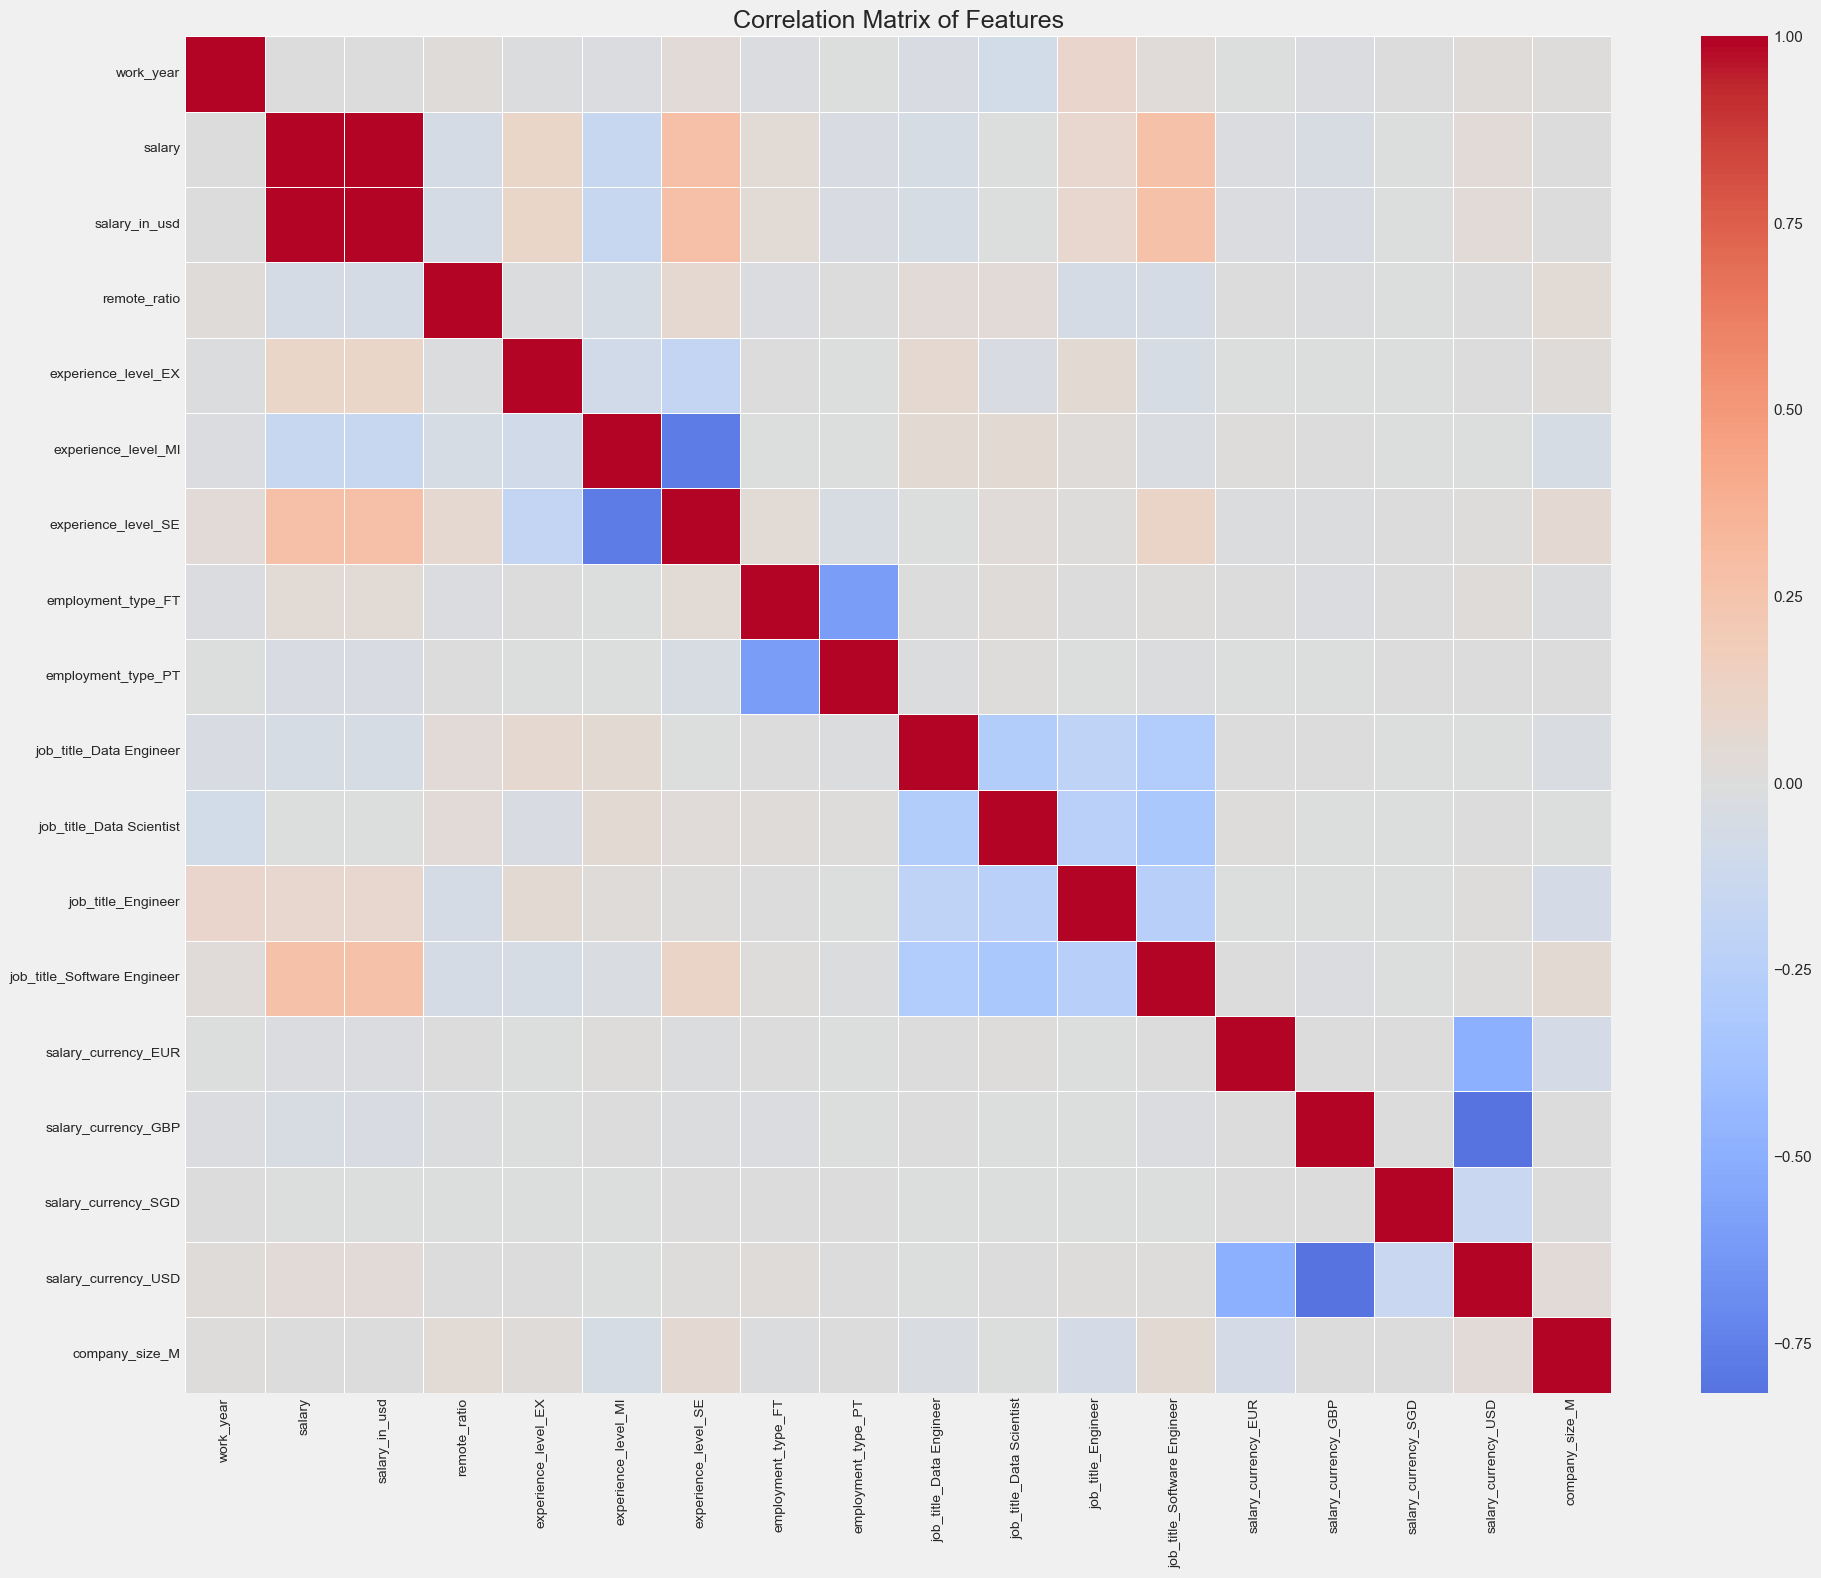

Top 10 features positively correlated with salary:
salary_in_usd                  1.000000
salary                         0.999942
experience_level_SE            0.280096
job_title_Software Engineer    0.265797
experience_level_EX            0.101342
job_title_Engineer             0.080772
employment_type_FT             0.046193
salary_currency_USD            0.035524
work_year                      0.004453
company_size_M                 0.003254
job_title_Data Scientist      -0.001627
Name: salary_in_usd, dtype: float64

Top 10 features negatively correlated with salary:
work_year                   0.004453
company_size_M              0.003254
job_title_Data Scientist   -0.001627
salary_currency_SGD        -0.007279
salary_currency_EUR        -0.014700
salary_currency_GBP        -0.032298
employment_type_PT         -0.033332
job_title_Data Engineer    -0.049920
remote_ratio               -0.059571
experience_level_MI        -0.153732
Name: salary_in_usd, dtype: float64


In [81]:
# Create dummy variables for categorical features
categorical_cols = ['experience_level', 'employment_type', 'job_title', 'salary_currency', 
                    'employee_residence', 'company_location', 'company_size']
numerical_cols = ['work_year', 'salary', 'salary_in_usd', 'remote_ratio']

# Select top job titles for simplified correlation analysis
top_job_titles = train_df['job_title'].value_counts().head(5).index.tolist()
df_corr = train_df[train_df['job_title'].isin(top_job_titles)].copy()

# Create dummy variables
df_dummies = pd.get_dummies(df_corr, columns=categorical_cols, drop_first=True)

# Calculate and plot correlation matrix
corr_matrix = df_dummies.corr()
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Correlation Matrix of Features', fontsize=18)
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Key salary correlations
salary_corr = corr_matrix['salary_in_usd'].sort_values(ascending=False)
print("Top 10 features positively correlated with salary:")
print(salary_corr.head(11))  # Including salary_in_usd itself
print("\nTop 10 features negatively correlated with salary:")
print(salary_corr.tail(10))

양의 상관관계 (연봉 상승과 함께 증가)  
	•	salary: 당연히 원래 연봉 자체이므로 강한 상관 -> 제거  
	•	experience_level_SE: Senior 직급 → 높은 연봉  
	•	job_title_Software Engineer: 소프트웨어 엔지니어 → 예측보다 높은 연봉  
	•	experience_level_EX: Executive 직급 → 확실한 프리미엄  
	•	salary_currency_USD: 달러로 연봉을 받는 경우 → 고소득 국가일 가능성 높음  
	•	company_size_M: 중견기업이 소기업보다 높은 연봉 줄 수 있음  
	•	work_year: 시간이 갈수록 연봉도 높아지는 트렌드 반영  




음의 상관관계  
	•	job_title_Engineer, Data Engineer, Data Scientist: 생각보다 연봉 평균이 낮음 (모든 샘플 기준이기에 가능성 있음)  
	•	experience_level_EN: Entry-level → 연봉 낮음  
	•	company_size_S: 소규모 회사 → 연봉 작음  
	•	salary_currency_EUR / GBP: 환율 등 고려했을 때 USD보다 낮게 환산되는 경우  
	•	remote_ratio: 원격근무 비율이 높다고 무조건 연봉이 높은 건 아님 (비선형적 관계 가능)  



종합 분석  
	•	상관계수는 대부분 0.2 미만 → 연봉에 영향을 주는 단일 변수는 강하지 않음  
	•	복합 피처 조합이나 비선형 모델 (예: Tree 계열, XGBoost 등) 적용이 효과적일 가능성 있음  
	•	중요 변수 후보:  
	•	experience_level_SE, experience_level_EX  
	•	job_title_Software Engineer  
	•	salary_currency_USD  
	•	work_year, company_size_M  

In [82]:
train_df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
129221,2024,EX,FT,Head of Machine Learning,245000,USD,245000,US,0,US,M
105182,2024,SE,FT,Engineer,202800,USD,202800,US,0,US,M
103831,2024,MI,FT,DevOps Engineer,60400,USD,60400,US,0,US,M
116850,2024,SE,FT,Data Engineer,116900,USD,116900,US,0,US,M
117146,2024,MI,FT,Data Engineer,117000,USD,117000,US,100,US,M


In [83]:
# 불필요한 컬럼 제거
cols_to_drop = ['salary', 'employee_residence', 'company_location']

train_df = train_df.drop(columns=cols_to_drop, errors='ignore')
valid_df = valid_df.drop(columns=cols_to_drop, errors='ignore')


print(train_df.columns)
print(valid_df.columns)

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_currency', 'salary_in_usd', 'remote_ratio', 'company_size'],
      dtype='object')
Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary_currency', 'salary_in_usd', 'remote_ratio', 'company_size'],
      dtype='object')


In [84]:
train_df.head()

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,remote_ratio,company_size
129221,2024,EX,FT,Head of Machine Learning,USD,245000,0,M
105182,2024,SE,FT,Engineer,USD,202800,0,M
103831,2024,MI,FT,DevOps Engineer,USD,60400,0,M
116850,2024,SE,FT,Data Engineer,USD,116900,0,M
117146,2024,MI,FT,Data Engineer,USD,117000,100,M


In [85]:
# 0 : 신입 ~ 1년미만 1 : 2~5년차 2 :5년 이상 3 : 관리자급
train_df['experience_level'] = train_df['experience_level'].map({'EN' : 0, 'MI' : 1, 'SE' : 2, 'EX' : 3})
valid_df['experience_level'] = valid_df['experience_level'].map({'EN' : 0, 'MI' : 1, 'SE' : 2, 'EX' : 3})

# 0 : 풀타임 1 : 파트타임 2 : 계약직 3 : 프리랜서
train_df['employment_type'] = train_df['employment_type'].map({'FT' : 0, 'PT' : 1, 'CT' : 2, 'FL' : 3})
valid_df['employment_type'] = valid_df['employment_type'].map({'FT' : 0, 'PT' : 1, 'CT' : 2, 'FL' : 3})


# 0 : 50명 이내 1 : 500명 이내 2 : 501명 이상
train_df['company_size'] = train_df['company_size'].map({'S' : 0, 'M' : 1, 'L' : 2})
valid_df['company_size'] = valid_df['company_size'].map({'S' : 0, 'M' : 1, 'L' : 2})

train_df.head()

,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,remote_ratio,company_size
129221,2024,3,0,Head of Machine Learning,USD,245000,0,1
105182,2024,2,0,Engineer,USD,202800,0,1
103831,2024,1,0,DevOps Engineer,USD,60400,0,1
116850,2024,2,0,Data Engineer,USD,116900,0,1
117146,2024,1,0,Data Engineer,USD,117000,100,1


In [93]:
# 원격근무 이진화

train_df['is_remote'] = (train_df['remote_ratio'] == 100).astype(int)
valid_df['is_remote'] = (valid_df['remote_ratio'] == 100).astype(int)


# job_title을 job_group화

def map_job_group(title):
    title = title.lower()
    if 'head' in title or 'lead' in title or 'director' in title or 'principal' in title or 'manager' in title or 'architect' in title:
        return 'Executive'
    elif 'machine learning' in title or 'ml' in title or 'deep learning' in title or 'ai' in title or 'vision' in title or ('scientist' in title and 'research' in title):
        return 'ML_AI'
    elif 'data scientist' in title or 'decision' in title or 'quant' in title or 'consultant' in title:
        return 'DataScience'
    elif 'engineer' in title and ('data' in title or 'platform' in title or 'infrastructure' in title or 'etl' in title):
        return 'DataEngineer'
    elif 'analyst' in title or 'bi' in title or 'analytics' in title or 'reporting' in title:
        return 'Analyst'
    else:
        return 'Other'

train_df['job_group'] = train_df['job_title'].apply(map_job_group)
valid_df['job_group'] = valid_df['job_title'].apply(map_job_group)


from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train_df['job_group'] = le.fit_transform(train_df['job_group'])
valid_df['job_group'] = le.fit_transform(valid_df['job_group'])


# 연봉 로그 변환

train_df['log_salary'] = np.log1p(train_df['salary_in_usd'])
valid_df['log_salary'] = np.log1p(valid_df['salary_in_usd'])


# job title을 토대로 산업군 컬럼 추가

def map_industry(title):
    title = title.lower()
    if any(x in title for x in ['quant', 'actuarial', 'risk', 'trader', 'finance']):
        return 'Finance'
    elif any(x in title for x in ['bio', 'biotech', 'clinical', 'medical', 'health']):
        return 'Healthcare'
    elif any(x in title for x in ['robotics', 'autonomous', 'vision']):
        return 'Robotics'
    elif any(x in title for x in ['marketing', 'sales', 'growth']):
        return 'Marketing'
    elif any(x in title for x in ['product', 'manager', 'owner']):
        return 'Product'
    elif any(x in title for x in ['cloud', 'devops', 'infrastructure']):
        return 'Cloud/Infrastructure'
    elif any(x in title for x in ['ai', 'ml', 'machine learning', 'deep learning']):
        return 'AI/ML'
    elif any(x in title for x in ['analytics', 'analyst', 'bi', 'report']):
        return 'Analytics'
    elif any(x in title for x in ['software', 'developer', 'engineer']):
        return 'Software'
    elif any(x in title for x in ['research', 'scientist']):
        return 'Research'
    else:
        return 'Other'

# 적용
train_df['industry_group'] = train_df['job_title'].apply(map_industry)
valid_df['industry_group'] = valid_df['job_title'].apply(map_industry)

# 숫자형으로 인코딩
from sklearn.preprocessing import LabelEncoder
le_ind = LabelEncoder()
train_df['industry_group'] = le_ind.fit_transform(train_df['industry_group'])
valid_df['industry_group'] = le_ind.transform(valid_df['industry_group'])



train_df.head()


,work_year,experience_level,employment_type,job_title,salary_currency,salary_in_usd,remote_ratio,company_size,is_remote,job_group,log_salary,industry_group
129221,2024,3,0,Head of Machine Learning,USD,245000,0,1,0,3,12.409018,0
105182,2024,2,0,Engineer,USD,202800,0,1,0,5,12.219980,10
103831,2024,1,0,DevOps Engineer,USD,60400,0,1,0,5,11.008761,2
116850,2024,2,0,Data Engineer,USD,116900,0,1,0,1,11.669083,10
117146,2024,1,0,Data Engineer,USD,117000,100,1,1,1,11.669938,10


In [ ]:
# 랜덤포레스트 학습

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 사용할 피처들 선택
features = ['work_year', 'experience_level', 'employment_type', 'company_size',
            'is_remote', 'job_group', 'industry_group']  # 숫자형/인코딩된 변수들

# 모델 정의
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 학습 (로그 변환된 연봉)
model.fit(train_df[features], train_df['log_salary'])a

# 검증 예측
y_pred_log = model.predict(valid_df[features])
y_pred = np.expm1(y_pred_log)  # 로그 복원
y_true = valid_df['salary_in_usd']

# 평가
rmse = mean_squared_error(y_true, y_pred, squared=False)
r2 = r2_score(y_true, y_pred)

print(f"✅ RMSE: {rmse:.2f}")
print(f"✅ R²: {r2:.4f}")

✅ RMSE: 66215.09
✅ R²: 0.1711


In [ ]:
# !pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 11.6 MB/s eta 0:00:00a 0:00:01


In [95]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 피처 및 타겟 지정
features = ['work_year', 'experience_level', 'employment_type', 'company_size',
            'is_remote', 'job_title', 'industry_group']  # job_group 대신 job_title 사용
target = 'log_salary'  # 로그 연봉

# CatBoost에서 처리할 범주형 피처 (index로 지정)
cat_features = ['experience_level', 'employment_type', 'company_size', 'job_title', 'industry_group']

# 모델 정의
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    random_seed=42,
    verbose=100
)

# 학습
model.fit(train_df[features], train_df[target], cat_features=cat_features)

# 예측
y_pred_log = model.predict(valid_df[features])
y_pred = np.expm1(y_pred_log)
y_true = valid_df['salary_in_usd']

# 평가
rmse = mean_squared_error(y_true, y_pred, squared=False)
r2 = r2_score(y_true, y_pred)

print(f"✅ RMSE: {rmse:.2f}")
print(f"✅ R²: {r2:.4f}")

0:	learn: 0.4163418	total: 11.8ms	remaining: 11.8s
100:	learn: 0.3535252	total: 647ms	remaining: 5.76s
200:	learn: 0.3525107	total: 1.27s	remaining: 5.06s
300:	learn: 0.3520529	total: 1.99s	remaining: 4.62s
400:	learn: 0.3516471	total: 2.66s	remaining: 3.97s
500:	learn: 0.3512590	total: 3.31s	remaining: 3.29s
600:	learn: 0.3509934	total: 3.96s	remaining: 2.63s
700:	learn: 0.3507552	total: 4.63s	remaining: 1.98s
800:	learn: 0.3505694	total: 5.28s	remaining: 1.31s
900:	learn: 0.3503605	total: 5.94s	remaining: 653ms
999:	learn: 0.3502216	total: 6.58s	remaining: 0us
✅ RMSE: 64089.67
✅ R²: 0.2234


In [90]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 사용할 피처들
features = ['work_year', 'experience_level', 'employment_type', 'company_size',
            'is_remote', 'job_group']  # 숫자형 변수만 사용

# 타겟: 로그 변환
y_train_log = np.log1p(train_df['salary_in_usd'])
y_valid_log = np.log1p(valid_df['salary_in_usd'])

# 모델 정의
model = HistGradientBoostingRegressor(random_state=42)

# 학습
model.fit(train_df[features], y_train_log)

# 예측 (로그 복원)
y_pred_log = model.predict(valid_df[features])
y_pred = np.expm1(y_pred_log)
y_true = valid_df['salary_in_usd']

# 평가
rmse = mean_squared_error(y_true, y_pred, squared=False)
r2 = r2_score(y_true, y_pred)

print(f"✅ RMSE: {rmse:.2f}")
print(f"✅ R²: {r2:.4f}")

✅ RMSE: 67057.44
✅ R²: 0.1499


In [92]:
train_df.job_title.unique()

array(['Head of Machine Learning', 'Engineer', 'DevOps Engineer',
       'Data Engineer', 'Analytics Engineer', 'Machine Learning Engineer',
       'Developer', 'Research Engineer', 'Data Scientist', 'Manager',
       'Frontend Engineer', 'Analyst', 'Software Engineer',
       'Applied Scientist', 'Data Analyst', 'Data Manager',
       'Business Intelligence', 'AI Software Engineer', 'Data Architect',
       'Product Manager', 'Platform Engineer', 'Data Specialist',
       'Associate', 'Solutions Architect', 'Site Reliability Engineer',
       'AI Engineer', 'Statistician', 'Business Intelligence Analyst',
       'Computer Vision Engineer', 'Product Designer',
       'Data Management Specialist', 'Research Scientist',
       'Data Integration Engineer', 'Marketing Science Partner',
       'Data Quality Analyst', 'Technical Lead', 'Statistical Programmer',
       'Data Management Lead', 'Solution Engineer', 'Postdoctoral Fellow',
       'Machine Learning Researcher', 'Systems Engineer',